Practica 2. Arboles de regresión.

Lozano Orona Samuel c20040642


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/12u1hZvKDBNKLMDNGNEN4bayutgjUFzfL/view?usp=sharing

file_id = "12u1hZvKDBNKLMDNGNEN4bayutgjUFzfL"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
df=pd.read_csv(url)
df.head()

Mounted at /content/drive


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [2]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
#ENTRENAR ARBOL DE REGRESIÓN
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [5]:
#EVALUAR EL MODELO
y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error cuadratico medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinacion (R^2): {r2_tree:.2f}")

Error cuadratico medio (MSE): 9188294.38
Coeficiente de determinacion (R^2): 0.92


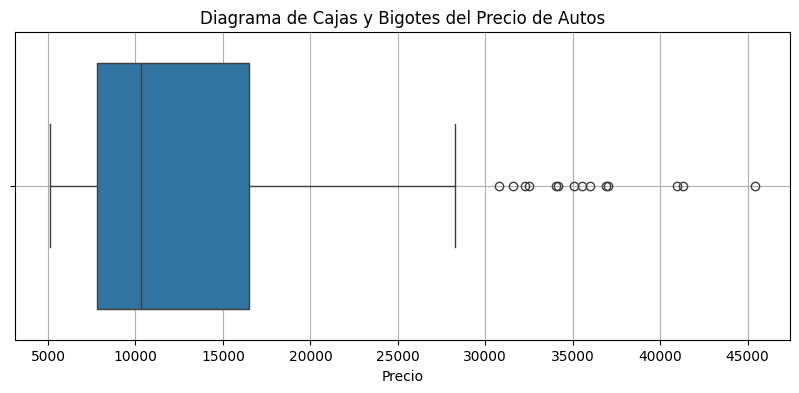

In [6]:
#DIAGRAMA PARA VISUALIZAR EL RANGO DE PRECIOS E INTERPRETAR
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'])

plt.title('Diagrama de Cajas y Bigotes del Precio de Autos')
plt.xlabel('Precio')
plt.grid(True)
plt.show()

In [7]:
rmse_tree = np.sqrt(mse_tree)
print(f"Raiz del error cuadratico medio (RMSE): {rmse_tree:.2f}")

Raiz del error cuadratico medio (RMSE): 3031.22


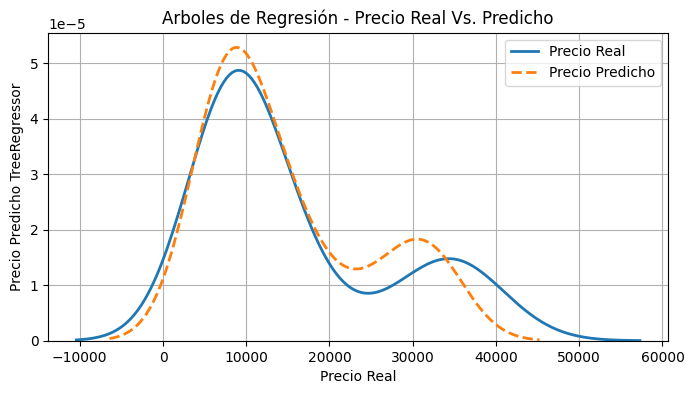

In [8]:
#COMPARACIÓN VISUAL DE DISTRIBUCIONES
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle = '--')

plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.title("Arboles de Regresión - Precio Real Vs. Predicho")
plt.grid(True)
plt.legend()
plt.show()

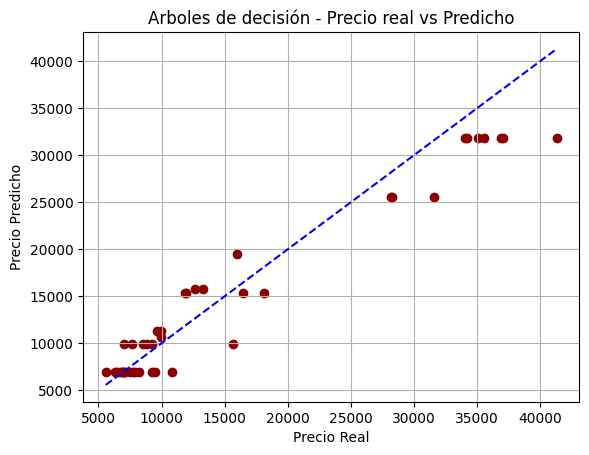

In [9]:
#DIAGRAMA DE DISPERSIÓN
plt.scatter(y_test, y_pred_tree, color = 'darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Arboles de decisión - Precio real vs Predicho')
plt.grid(True)
plt.show()

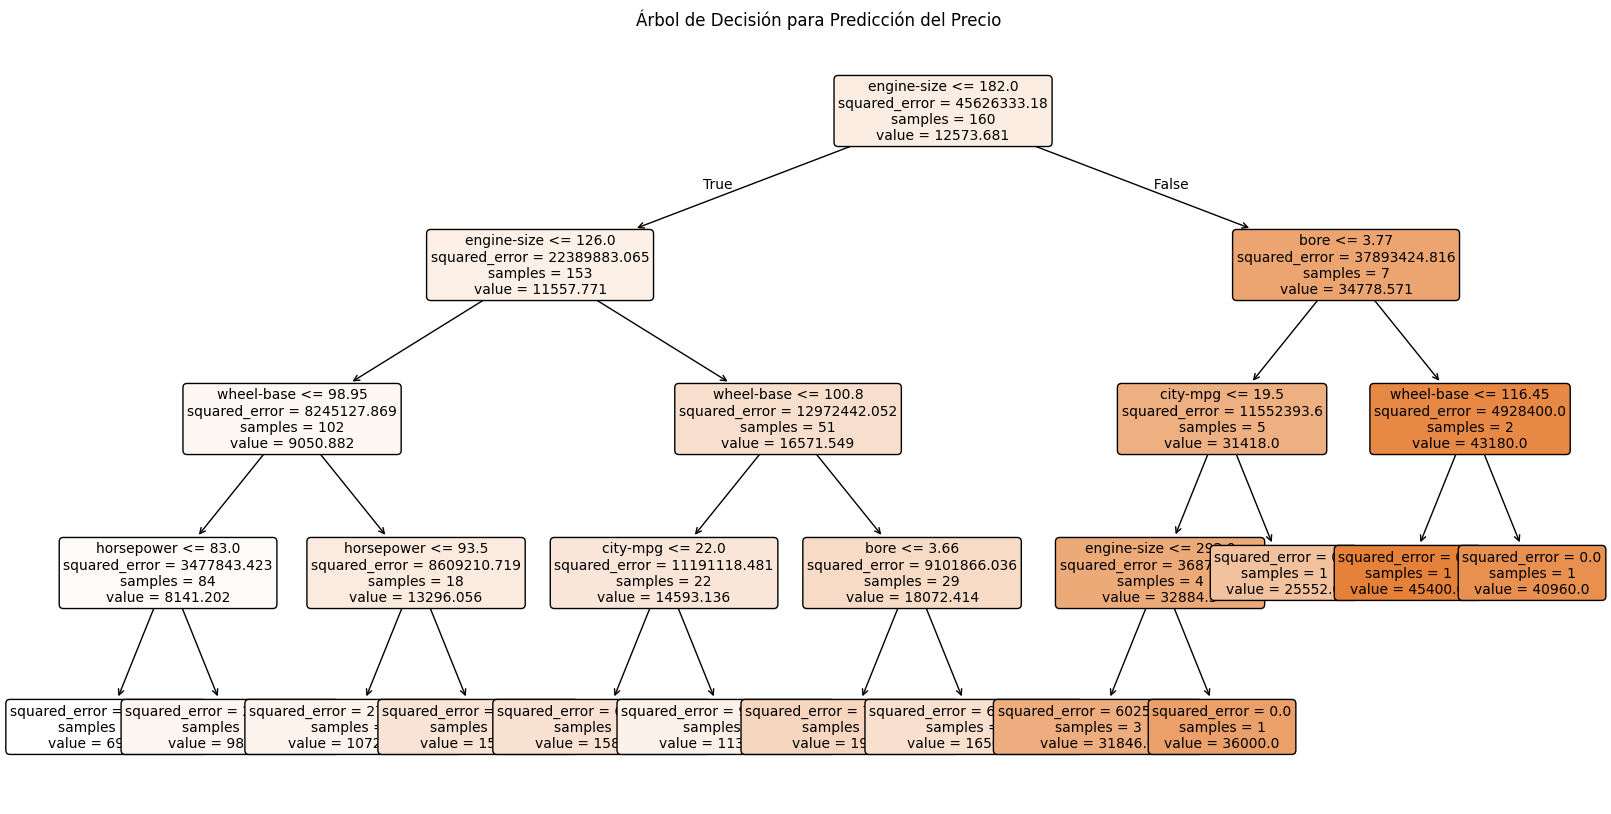

In [10]:
from sklearn.tree import plot_tree

#Visualizar el árbol de decisión
plt.figure(figsize=(20,10))
plot_tree(tree_model, filled=True,
          feature_names=X.columns,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

Error cuadratico medio (MSE): 7896468.85
Coeficiente de determinacion (R^2): 0.94
Raiz del error cuadratico medio (RMSE): 2810.07


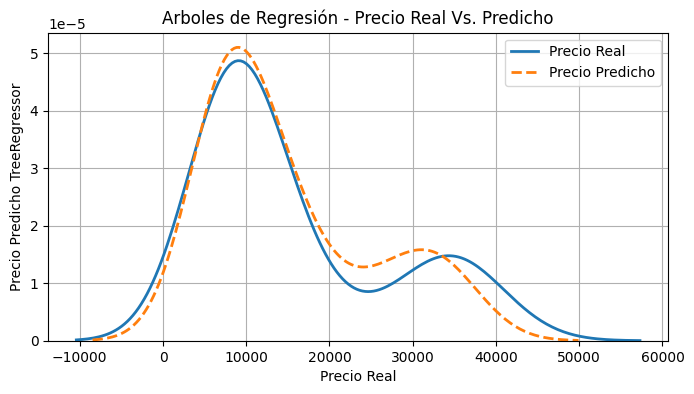

In [11]:
#AGREGAR PROFUNDIDAD AL ÁRBOL
tree_model = DecisionTreeRegressor(random_state=42, max_depth=9)
tree_model.fit(X_train, y_train)

y_pred_tree= tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error cuadratico medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinacion (R^2): {r2_tree:.2f}")

#Calcular el RMSE
rmse_tree = np.sqrt(mse_tree)
print(f"Raiz del error cuadratico medio (RMSE): {rmse_tree:.2f}")

#Comparacion visual
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle = '--')

plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.title("Arboles de Regresión - Precio Real Vs. Predicho")
plt.grid(True)
plt.legend()
plt.show()

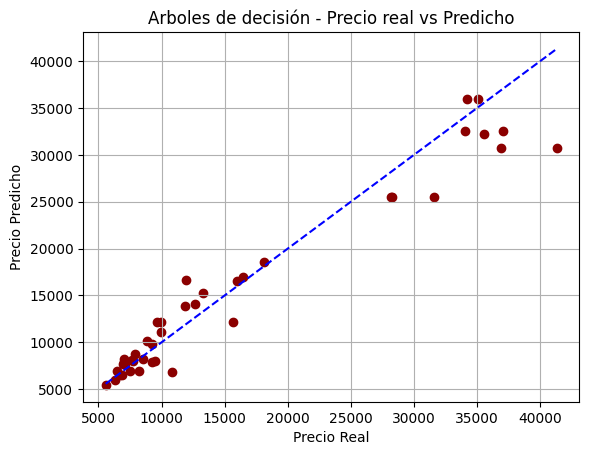

In [12]:
#DIAGRAMA DE DISPERSIÓN
plt.scatter(y_test, y_pred_tree, color = 'darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Arboles de decisión - Precio real vs Predicho')
plt.grid(True)
plt.show()

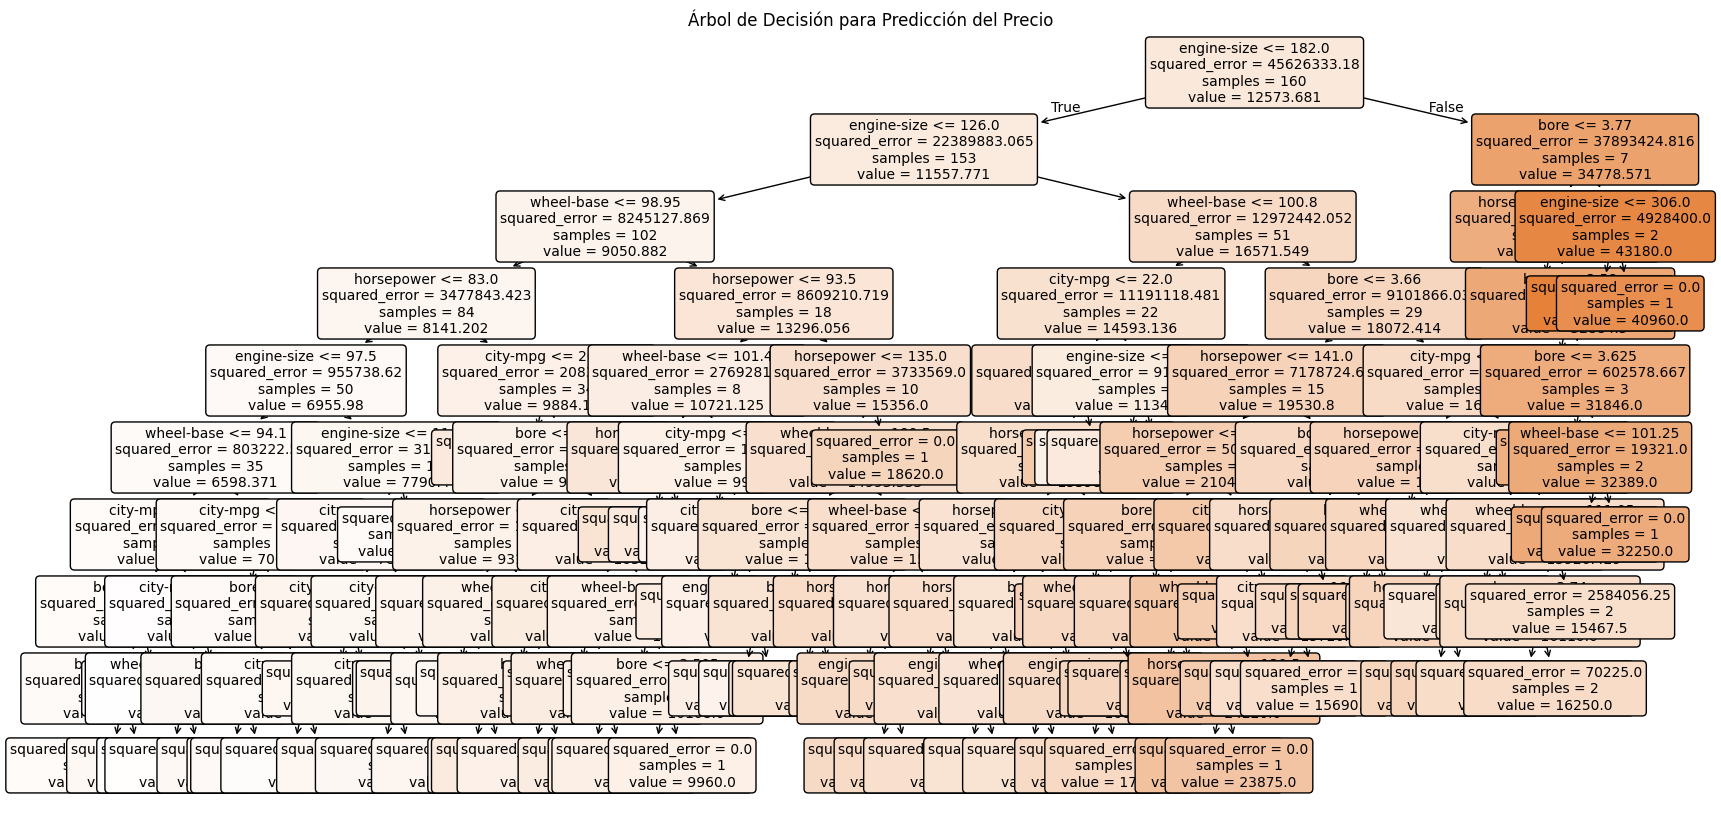

In [13]:
from sklearn.tree import plot_tree

#Visualizar el árbol de decisión
plt.figure(figsize=(20,10))
plot_tree(tree_model, filled=True,
          feature_names=X.columns,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

Error cuadratico medio (MSE): 6207944.08
Coeficiente de determinacion (R^2): 0.95
Raiz del error cuadratico medio (RMSE): 2491.57


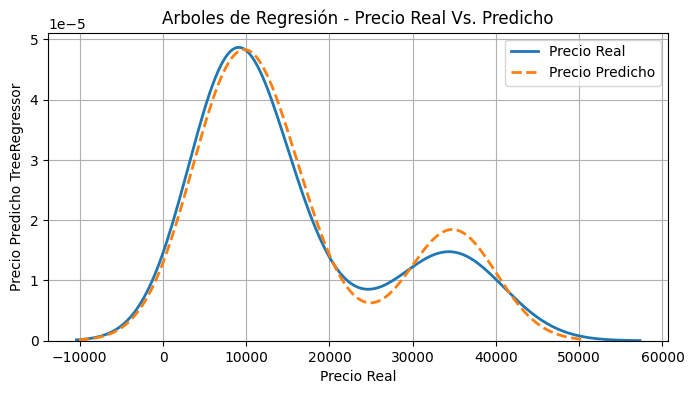

In [14]:
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=7,
    min_samples_split=10, #Número minimo de muestras requeridas para dividir un nodo
    min_samples_leaf=2,   #Número minimo de muestras qeu debe tener una hoja
    max_features='sqrt',  #Número máximo de caracteristicas a considerar al dividir los nodos
    max_leaf_nodes=20     #
)
tree_model.fit(X_train, y_train)
y_pred_tree= tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error cuadratico medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinacion (R^2): {r2_tree:.2f}")

#Calcular el RMSE
rmse_tree = np.sqrt(mse_tree)
print(f"Raiz del error cuadratico medio (RMSE): {rmse_tree:.2f}")

#Comparacion visual
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle = '--')

plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.title("Arboles de Regresión - Precio Real Vs. Predicho")
plt.grid(True)
plt.legend()
plt.show()

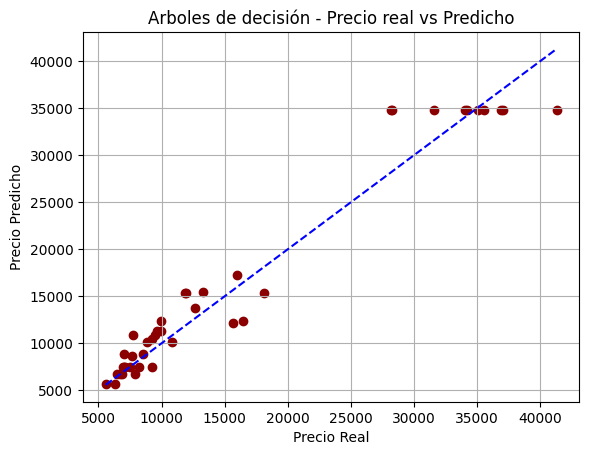

In [15]:
#DIAGRAMA DE DISPERSIÓN
plt.scatter(y_test, y_pred_tree, color = 'darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Arboles de decisión - Precio real vs Predicho')
plt.grid(True)
plt.show()

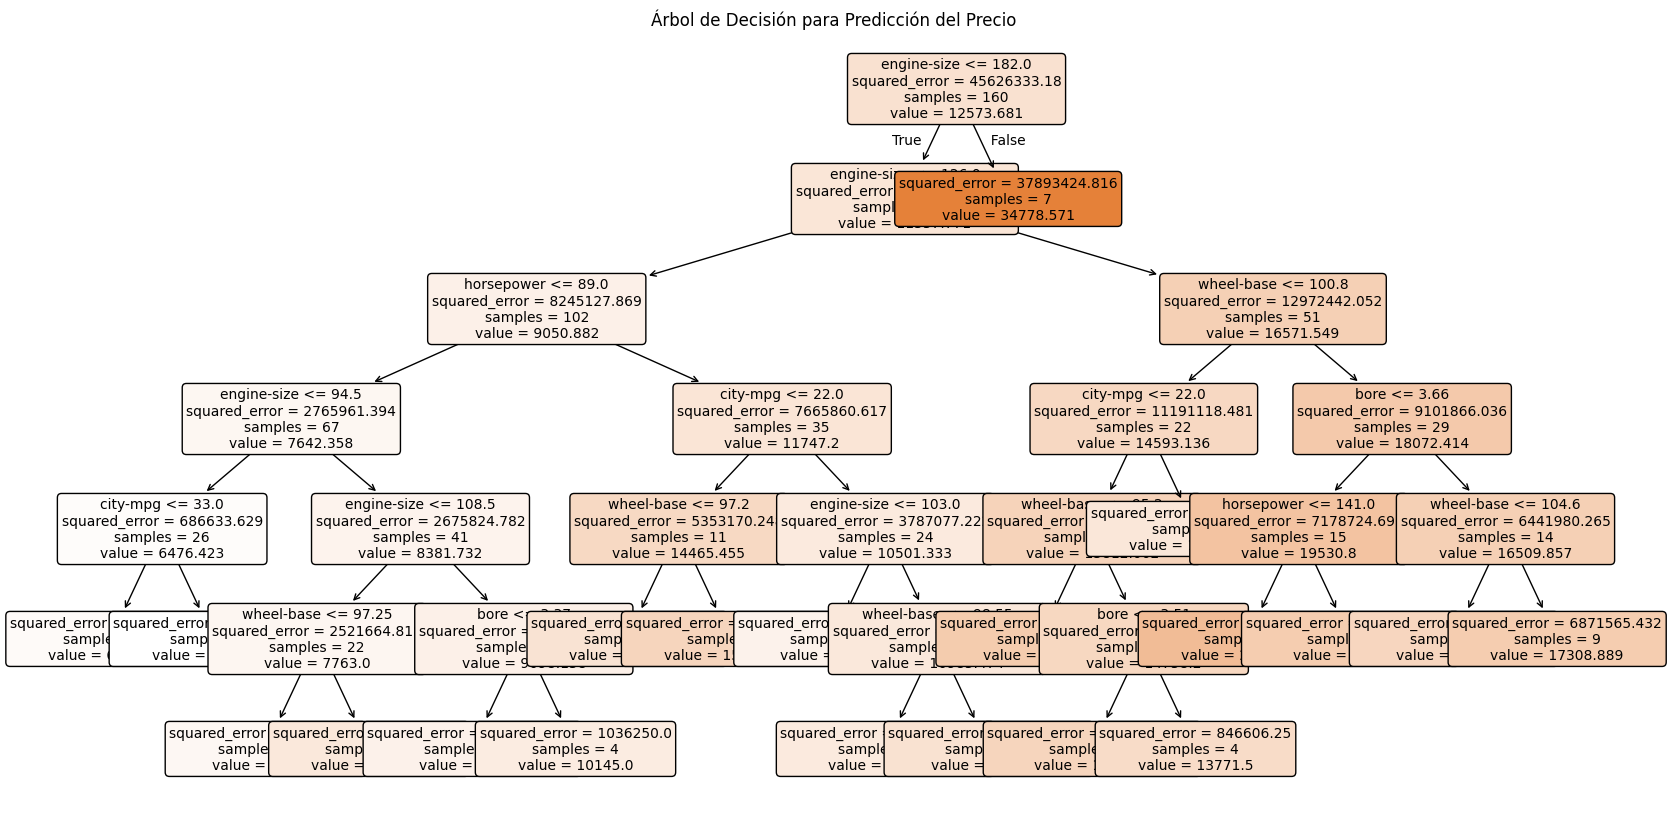

In [16]:
from sklearn.tree import plot_tree

#Visualizar el árbol de decisión
plt.figure(figsize=(20,10))
plot_tree(tree_model, filled=True,
          feature_names=X.columns,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()